# HANDS-ON SESSION 7
## Python + Google Colab + BigQuery — Data Cleaning & EDA TheLook Ecommerce

**Dataset:** `bigquery-public-data.thelook_ecommerce`  
**Level:** Basic / Pemula

### Alur Project
**BigQuery → Pandas → Cleaning → EDA → Insight**

Dataset tetap menggunakan TheLook Ecommerce agar project berkesinambungan dari sesi sebelumnya.

> Pada sesi ini fokusnya adalah **data cleaning dan exploratory data analysis (EDA) sederhana**. Tidak menggunakan JOIN kompleks.


## 1. Setup Google Colab & BigQuery

In [44]:
!pip -q install google-cloud-bigquery db-dtypes


In [45]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "latihan-pertama-505507"
client = bigquery.Client(project=PROJECT_ID)

print("Connected to:", PROJECT_ID)


Connected to: latihan-pertama-505507


## 2. Cek Dataset TheLook Ecommerce

In [46]:
query = '''
SELECT
  table_name
FROM `bigquery-public-data.thelook_ecommerce.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
'''

client.query(query).to_dataframe()


,table_name
0,distribution_centers
1,events
2,inventory_items
3,order_items
4,orders
5,products
6,users


# BAGIAN A — AMBIL DATA DARI BIGQUERY

## 3. Ambil Data Orders

Kita gunakan tabel `orders` sebagai dataset utama.


In [47]:
query = '''
SELECT
  order_id,
  user_id,
  status,
  created_at
FROM `bigquery-public-data.thelook_ecommerce.orders`
'''

df = client.query(query).to_dataframe()

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 124920
Columns: 4


## 4. Melihat Data Awal

In [48]:
df.head()
df.tail()


,order_id,user_id,status,created_at
124915,124883,99970,Shipped,2025-06-23 04:30:06+00:00
124916,124895,99976,Shipped,2022-12-11 11:30:28+00:00
124917,124896,99977,Shipped,2023-04-28 12:05:45+00:00
124918,124904,99984,Shipped,2024-05-25 10:59:28+00:00
124919,124919,99997,Shipped,2022-06-06 19:31:28+00:00


# BAGIAN B — DATA UNDERSTANDING

## 5. Cek Struktur Data

In [49]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124920 entries, 0 to 124919
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype              
---  ------      --------------   -----              
 0   order_id    124920 non-null  Int64              
 1   user_id     124920 non-null  Int64              
 2   status      124920 non-null  object             
 3   created_at  124920 non-null  datetime64[us, UTC]
dtypes: Int64(2), datetime64[us, UTC](1), object(1)
memory usage: 4.1+ MB


## 6. Cek Jumlah Baris dan Kolom

In [50]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])


Jumlah baris : 124920
Jumlah kolom : 4


## 7. Cek Missing Value

Hitung nilai kosong setiap kolom.


In [51]:
missing = df.isna().sum().sort_values(ascending=False)
missing


,0
order_id,0
user_id,0
status,0
created_at,0


## 8. Cek Duplicate

In [52]:
duplicate_count = df.duplicated().sum()

print("Jumlah duplicate:", duplicate_count)


Jumlah duplicate: 0


# BAGIAN C — DATA CLEANING

## 9. Menghapus Duplicate

Untuk dataset latihan, duplicate dapat dihapus jika memang bukan record transaksi yang berbeda.


In [53]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Sebelum :", before)
print("Sesudah :", after)
print("Dihapus :", before - after)


Sebelum : 124920
Sesudah : 124920
Dihapus : 0


## 10. Cleaning Kolom Tanggal

Pastikan `created_at` bertipe datetime.


In [54]:
import pandas as pd

df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce"
)

print(df["created_at"].dtype)


datetime64[us, UTC]


## 11. Cek Missing Setelah Konversi Tanggal

In [55]:
df["created_at"].isna().sum()


np.int64(0)

## 12. Membuat Kolom Tanggal

Kolom `order_date` akan berguna untuk analisis harian.


In [56]:
#jadi order_date adalah kolom baru yang dibuat untuk menyimpan hasil pengambilan
#hanya tanggal dari created_at
#kemudian kolom yang sudah terbentuk di panggil kembali, jangan lupa double [[]]
df["order_date"] = df["created_at"].dt.date

df[["created_at", "order_date"]].head()


,created_at,order_date
0,2020-08-16 17:21:52+00:00,2020-08-16
1,2024-12-13 07:35:20+00:00,2024-12-13
2,2023-10-03 04:21:02+00:00,2023-10-03
3,2025-12-07 03:59:07+00:00,2025-12-07
4,2026-01-23 08:54:58+00:00,2026-01-23


## 13. Validasi Status

Lihat kategori status yang tersedia.


In [57]:
#nilai kosong atau baris kosong tetap dihitung
df["status"].value_counts(dropna=False)


,count
status,
Shipped,37438
Complete,31286
Processing,25063
Cancelled,18893
Returned,12240


# BAGIAN D — EDA DASAR

## 14. Total Orders

In [58]:
total_orders = len(df)

print("Total Orders:", total_orders)


Total Orders: 124920


## 15. Orders per Status

In [59]:
status_summary = (
    df["status"]
      .value_counts()
      .reset_index()
)

status_summary.columns = [
    "status",
    "total_orders"
]

status_summary


,status,total_orders
0,Shipped,37438
1,Complete,31286
2,Processing,25063
3,Cancelled,18893
4,Returned,12240


## 16. Complete Orders

In [60]:
complete_orders = (df["status"] == "Complete").sum()

print("Complete Orders:", complete_orders)


Complete Orders: 31286


## 17. Complete Rate

In [61]:
complete_rate = round(
    complete_orders / total_orders * 100,
    2
)

print("Complete Rate:", complete_rate, "%")


Complete Rate: 25.04 %


## 18. Orders per Date

In [62]:
daily_orders = (
    df.groupby("order_date")
      .size()
      .reset_index(name="total_orders")
      .sort_values("total_orders", ascending=False)
)

daily_orders.head(10)


,order_date,total_orders
2736,2026-09-07,1678
2735,2026-09-06,1080
2734,2026-09-05,758
2733,2026-09-04,595
2732,2026-09-03,397
2731,2026-09-02,337
2728,2026-08-30,285
2730,2026-09-01,255
2729,2026-08-31,253
2723,2026-08-25,248


## 19. Orders per Month

In [63]:
df["month"] = (
    df["created_at"]
      .dt.to_period("M")
      .astype(str)
)

monthly_orders = (
    df.groupby("month")
      .size()
      .reset_index(name="total_orders")
)

monthly_orders.head(10)


/tmp/ipykernel_1200/1895575624.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,month,total_orders
0,2019-01,3
1,2019-02,22
2,2019-03,38
3,2019-04,57
4,2019-05,76
5,2019-06,74
6,2019-07,107
7,2019-08,123
8,2019-09,118
9,2019-10,141


## 20. Visualisasi Monthly Orders

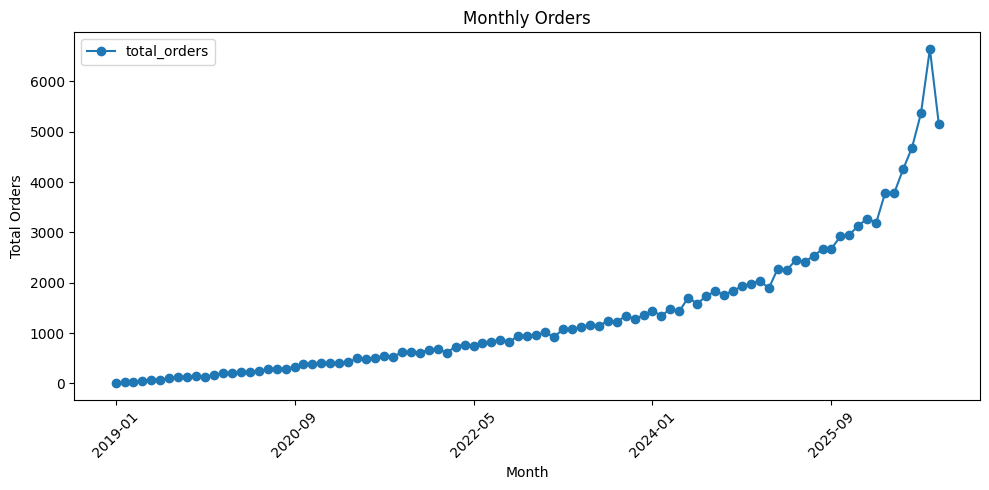

In [64]:
import matplotlib.pyplot as plt

monthly_orders.plot(
    x="month",
    y="total_orders",
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 21. Visualisasi Status

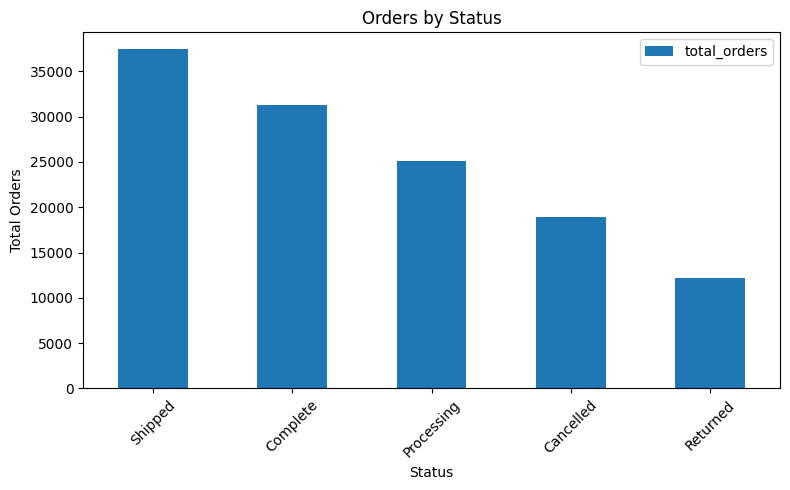

In [65]:
status_summary.plot(
    x="status",
    y="total_orders",
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Status")
plt.xlabel("Status")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# BAGIAN E — BUSINESS QUESTIONS

## 22. Pertanyaan Analisis

Gunakan hasil EDA untuk menjawab:

1. Berapa total order?
2. Status apa yang paling banyak?
3. Berapa Complete Orders?
4. Berapa Complete Rate?
5. Bulan mana yang memiliki order terbanyak?
6. Hari mana yang memiliki order terbanyak?


In [66]:
print("===== KEY METRICS =====")
print("Total Orders   :", total_orders)
print("Complete Orders:", complete_orders)
print("Complete Rate  :", complete_rate, "%")
print()

print("Status Summary:")
display(status_summary)

print("Top 10 Dates:")
display(daily_orders.head(10))

print("Monthly Orders:")
display(monthly_orders)


===== KEY METRICS =====
Total Orders   : 124920
Complete Orders: 31286
Complete Rate  : 25.04 %

Status Summary:


,status,total_orders
0,Shipped,37438
1,Complete,31286
2,Processing,25063
3,Cancelled,18893
4,Returned,12240


Top 10 Dates:


,order_date,total_orders
2736,2026-09-07,1678
2735,2026-09-06,1080
2734,2026-09-05,758
2733,2026-09-04,595
2732,2026-09-03,397
2731,2026-09-02,337
2728,2026-08-30,285
2730,2026-09-01,255
2729,2026-08-31,253
2723,2026-08-25,248


Monthly Orders:


,month,total_orders
0,2019-01,3
1,2019-02,22
2,2019-03,38
3,2019-04,57
4,2019-05,76
...,...,...
88,2026-05,4249
89,2026-06,4682
90,2026-07,5362
91,2026-08,6641


# BAGIAN F — HANDS-ON CLEANING CHECK

## 23. Final Data Quality Check

In [67]:
print("===== FINAL DATA QUALITY CHECK =====")
print("Rows            :", len(df))
print("Columns         :", len(df.columns))
print("Missing values  :", int(df.isna().sum().sum()))
print("Duplicate rows  :", int(df.duplicated().sum()))
print("Invalid dates   :", int(df["created_at"].isna().sum()))


===== FINAL DATA QUALITY CHECK =====
Rows            : 124920
Columns         : 6
Missing values  : 0
Duplicate rows  : 0
Invalid dates   : 0


## 24. Simpan Dataset Bersih

Dataset ini akan menjadi input untuk sesi berikutnya.


In [68]:
#clean_file = "thelook_clean_session7.csv"

#df.to_csv(
    #clean_file,
    #index=False
#)

#print("File berhasil dibuat:", clean_file)


File berhasil dibuat: thelook_clean_session7.csv


In [69]:
#from google.colab import files

#files.download("thelook_clean_session7.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# MINI PROJECT SESI 7

### Business Question
**“Bagaimana kondisi order TheLook Ecommerce setelah data dibersihkan?”**

Peserta harus menghasilkan:
- Clean dataset
- Total Orders
- Status Summary
- Complete Orders
- Complete Rate
- Daily Orders
- Monthly Orders
- Minimal 2 insight dari hasil EDA


# LATIHAN MANDIRI

### Soal 1
Cari 10 tanggal dengan jumlah order terbanyak.

### Soal 2
Cari bulan dengan jumlah order terbanyak.

### Soal 3
Hitung persentase masing-masing status.

### Soal 4
Buat satu visualisasi tambahan.

### Soal 5
Tuliskan minimal 2 insight berdasarkan data.

**Hint:** gunakan `groupby()`, `value_counts()`, `sort_values()`, dan filtering.


In [94]:
#Tulis kode Anda di sini


print ("hasil1",  (TOP_jumlah_order))
print ("hasil2", (top_month))
print ("hasil3", (status_summary))


hasil1       month  Top10_jumlah_order
91  2026-08                6641
90  2026-07                5362
92  2026-09                5149
89  2026-06                4682
88  2026-05                4249
86  2026-03                3784
87  2026-04                3775
84  2026-01                3275
85  2026-02                3192
83  2025-12                3131
hasil2       month  total_orders
91  2026-08          6641
hasil3        status  total_orders  percentage
0     Shipped         37438       29.97
1    Complete         31286       25.04
2  Processing         25063       20.06
3   Cancelled         18893       15.12
4    Returned         12240        9.80


In [75]:
#SOAL 1. Cari 10 tanggal dengan order terbanyak

TOP_jumlah_order = (
    df.groupby("month")
      .size()
      .reset_index(name="Top10_jumlah_order")
      .sort_values("Top10_jumlah_order", ascending=False)
      .head(10)
)

TOP_jumlah_order


,month,Top10_jumlah_order
91,2026-08,6641
90,2026-07,5362
92,2026-09,5149
89,2026-06,4682
88,2026-05,4249
86,2026-03,3784
87,2026-04,3775
84,2026-01,3275
85,2026-02,3192
83,2025-12,3131


In [76]:
a = (df.groupby("month").size())
a

,0
month,
2019-01,3
2019-02,22
2019-03,38
2019-04,57
2019-05,76
...,...
2026-05,4249
2026-06,4682
2026-07,5362


In [77]:
b = df.month.value_counts()
b

,count
month,
2026-08,6641
2026-07,5362
2026-09,5149
2026-06,4682
2026-05,4249
...,...
2019-06,74
2019-04,57
2019-03,38


In [78]:
# SOAL 2. Cari bulan dengan order terbanyak
top_month = (
    df.groupby("month")
      .size()
      .reset_index(name="total_orders")
      .sort_values("total_orders", ascending=False)
      .head(1)
)

top_month

,month,total_orders
91,2026-08,6641


In [79]:
# SOAL 3. hitung presentase masing-masing status
df["status"].value_counts()

,count
status,
Shipped,37438
Complete,31286
Processing,25063
Cancelled,18893
Returned,12240


In [80]:
#mengelompokkan kolom status
complete_status1 = (
    df["status"]
      .value_counts()
      .reset_index()
)

#status_summary adalah adalah dataframe
status_summary.columns = ["status", "total_orders"]

status_summary["percentage"] = (
    status_summary["total_orders"]
    / status_summary["total_orders"].sum()
    * 100
).round(2)

status_summary

,status,total_orders,percentage
0,Shipped,37438,29.97
1,Complete,31286,25.04
2,Processing,25063,20.06
3,Cancelled,18893,15.12
4,Returned,12240,9.80


In [81]:
status_summary["total_orders"]

,total_orders
0,37438
1,31286
2,25063
3,18893
4,12240


In [82]:
status_summary.columns

Index(['status', 'total_orders', 'percentage'], dtype='object')

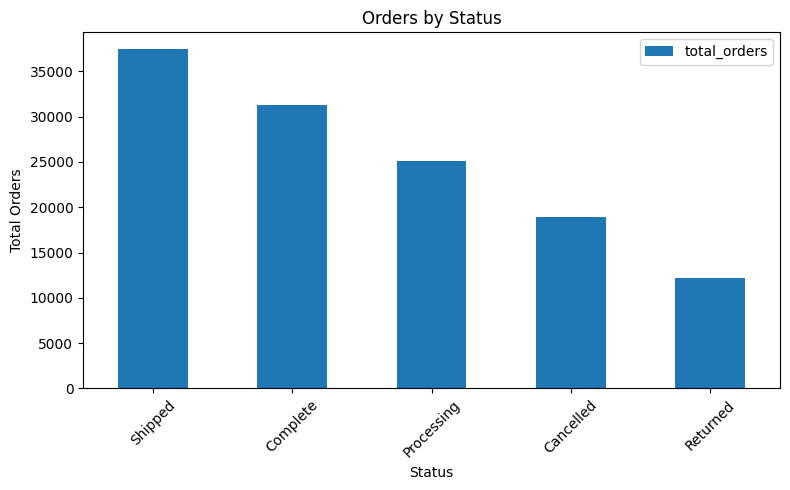

In [83]:
#Soal 4. Buat visualisasi tambahan
status_summary.plot(
    x="status",
    y="total_orders",
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Status")
plt.xlabel("Status")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

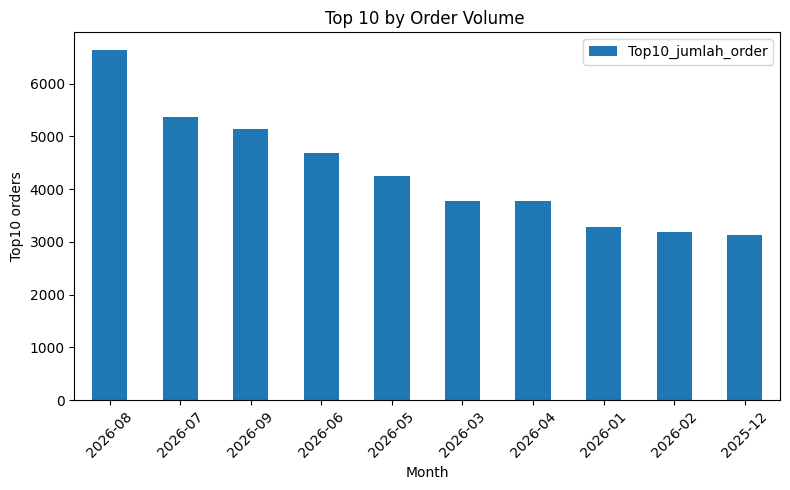

In [88]:
TOP_jumlah_order.plot(
    x="month",
    y="Top10_jumlah_order",
    kind="bar",
    figsize=(8,5)
)

plt.title("Top 10 by Order Volume ")
plt.xlabel("Month")
plt.ylabel("Top10 orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Soal NO 5. Berikan 2 insight

1. Pengiriman lebih banyak daripada pemesanan yang komplit, artinya ada sejumlah barang yang dikembalikan. Ini bisa jadi sebuah kerugian jika
pengembalian dibebankan ke perusahaan tanpa pertimbangan dari segi revenue atau biaya admin.

2.Transaksi terjadi paling banyak terjadi di bulan agustus, kita bisa cek ada moment apa disana yang menyebabkan jumlah transaksi tinggi.
 Kemudian kita bisa cari untuk bulan terendah dan bisa memberikan voucher atau cashback
di bulan tersebut agar bisa meningkatkan pendapatan perusahaan.

# OUTPUT & HANDOFF KE SESI 8

### Output Sesi 7
- Notebook Google Colab
- Dataset bersih `thelook_clean_session7.csv`
- Summary status
- Daily / monthly analysis
- Visualisasi dasar
- Minimal 2 insight

### Handoff
**Sesi 7: Cleaning + EDA**
↓
**Sesi 8: Analisis Python lanjutan**

Project tetap menggunakan dataset TheLook Ecommerce yang sama.
